In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS_PUBLIC = PROJECT_ROOT / "artifacts" / "public"
DATA_PUBLIC = PROJECT_ROOT / "data" / "public"
MODELS_PUBLIC = PROJECT_ROOT / "models" / "public"

# Notebook de tuning

- En este notebook realizamos tuning y validación robusta del modelo con split temporal fijo.
- Comparamos `LogisticRegression` y `GradientBoosting` con `GridSearchCV`, y además evaluamos variantes de balanceo (`class_weight`, under/over sampling y `SMOTE`) sobre Logistic Regression.
- Seleccionamos el champion con criterio de negocio (`Top-2` > `balanced_accuracy` > `f1_pos`) y lo exportamos para inferencia en `app.py` como base del MVP.


## Protocolo de validación (Day 04)

### 1) Objetivo
Evaluar modelos de recomendación de proveedor sin fuga temporal y con métricas útiles para negocio.

### 2) Regla de partición
- Split **temporal fijo**: `train = pasado`, `test = futuro`.
- No mezclar fechas entre train/test.
- Mantener este split para todas las comparaciones del día.

### 3) Métricas oficiales
- **Por fila (diagnóstico):**
  - `accuracy`
  - `balanced_accuracy`
  - `f1` de la clase positiva (`target_elegido = 1`)
- **Por evento (negocio):**
  - `Top-1 hit` por `event_id`
  - `Top-2 hit` por `event_id`

### 4) Baselines obligatorios
Comparar siempre el modelo contra:
1. Baseline `más barato` (Top-1/Top-2 por evento usando `coste_min_dia_proveedor`).
2. Baseline histórico top proveedores del train:
   - `siempre proveedor #1`
   - `proveedor #1 + proveedor #2` en Top-2.

### 5) Reglas anti-fuga
- No usar columnas de leakage (IDs operativos del resultado, variables derivadas del target, info futura).
- El preprocesado de inferencia debe ser idéntico al de entrenamiento.

### 6) Criterio de aceptación (gate)
Un modelo solo se promueve si mejora de forma estable al baseline de negocio en métricas por evento (`Top-1/Top-2`) y no empeora de forma relevante `balanced_accuracy`/`f1` clase positiva.


## Librerías

In [2]:
# Librerías

import sys
from pathlib import Path

import pandas as pd
pd.set_option("display.max_columns", None)

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Sube de notebooks/ a la raíz del repo
sys.path.append(str(Path.cwd().parent))

# Importamos funciones
import src.ml.shared.functions as fc

%matplotlib inline 
%load_ext autoreload
%autoreload 2


## Carga de datos

In [3]:
df = fc.load_data("dataset_modelo_proveedor_v2_candidates.csv")
df_model = fc.df_model_knn_feature(df).sort_values("fecha_evento").reset_index(drop=True)


## Validación Baseline Fijos

In [4]:
# Definir columnas y hacer split temporal fijo (mismo que usarás luego en modelos)
feature_cols_num, feature_cols_cat, target_col = fc.get_feature_columns_v2()

X_train, X_test, y_train, y_test, train_df, test_df, cutoff_date = fc.split_temporal_v2(
    df_model,
    feature_cols_num=feature_cols_num,
    feature_cols_cat=feature_cols_cat,
    target_col=target_col,
    train_frac=0.8
)

# Baselines de negocio (sin modelo)
baseline_pack = fc.compute_business_baselines(train_df, test_df)
baseline_table = baseline_pack["baseline_table"].copy()

print(f"Cutoff temporal: {pd.to_datetime(cutoff_date).date()}")
print(f"Proveedor top-1 train: {baseline_pack['top_provider_train']}")
print(f"Proveedor top-2 train: {baseline_pack['second_provider_train']}")
display(baseline_table)

Cutoff temporal: 2028-02-21
Proveedor top-1 train: SUPPLIER_009
Proveedor top-2 train: SUPPLIER_050


,baseline,top1_hit,top2_hit
0,Más barato,0.306494,0.535131
1,Siempre SUPPLIER_009,0.800608,0.800608
2,SUPPLIER_009+SUPPLIER_050,0.800608,0.858336


## Ensemble y comparación contra Baseline

In [5]:
# Logistic Regression contra Baseline

model = Pipeline([
    ("scaler", StandardScaler()),  # <- AJUSTÉ PORQUE en LR el escalado mejora convergencia y estabilidad
    ("logreg", LogisticRegression(max_iter=4000, random_state=0))  # <- AJUSTÉ PORQUE evitamos el warning de convergencia
])
res = fc.evaluate_model_vs_baselines(model, X_train, y_train, X_test, y_test, train_df, test_df)

print("Row metrics:", res["row_metrics"])
print("Event metrics:", res["event_metrics"])
display(res["comparison_table"])


Row metrics: {'accuracy': 0.9334835986955687, 'balanced_accuracy': 0.7827490455774113, 'f1_pos': 0.6881043400044974}
Event metrics: {'top1_hit': 0.759589821496392, 'top2_hit': 0.858336498290923}


,baseline,top1_hit,top2_hit
0,Modelo,0.759590,0.858336
1,Más barato,0.306494,0.535131
2,Siempre SUPPLIER_009,0.800608,0.800608
3,SUPPLIER_009+SUPPLIER_050,0.800608,0.858336


# Hiperparámetros

In [6]:
# Reutilizamos el mismo split temporal fijo para tuning
X_train_hyper, X_test_hyper = X_train, X_test
y_train_hyper, y_test_hyper = y_train, y_test
train_df_hyper, test_df_hyper = train_df, test_df

print("Cutoff temporal:", pd.to_datetime(cutoff_date).date())
tscv = TimeSeriesSplit(n_splits=4)


Cutoff temporal: 2028-02-21


In [7]:
# === GridSearch: Logistic Regression ===
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=0))
])

param_grid_lr = {
    "logreg__C": [0.1, 1.0, 3.0, 10.0],
    "logreg__solver": ["lbfgs"],
    "logreg__penalty": ["l2"],
    "logreg__class_weight": [None, "balanced"],
    "logreg__max_iter": [3000]
}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="balanced_accuracy",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train_hyper, y_train_hyper)

print("LR best score (CV):", round(grid_lr.best_score_, 4))
print("LR best params:", grid_lr.best_params_)


Fitting 4 folds for each of 8 candidates, totalling 32 fits


LR best score (CV): 0.8583
LR best params: {'logreg__C': 1.0, 'logreg__class_weight': 'balanced', 'logreg__max_iter': 3000, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}


In [8]:
# === GridSearch: Gradient Boosting ===
gb = GradientBoostingClassifier(random_state=0)

param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    scoring="balanced_accuracy",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)
grid_gb.fit(X_train_hyper, y_train_hyper)

print("GB best score (CV):", round(grid_gb.best_score_, 4))
print("GB best params:", grid_gb.best_params_)


Fitting 4 folds for each of 24 candidates, totalling 96 fits


GB best score (CV): 0.7273
GB best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [9]:
# === Evaluación final contra baselines de negocio (test temporal) ===
res_lr = fc.evaluate_model_vs_baselines(
    model=grid_lr.best_estimator_,
    X_train=X_train_hyper, y_train=y_train_hyper,
    X_test=X_test_hyper, y_test=y_test_hyper,
    train_df=train_df_hyper, test_df=test_df_hyper
)

res_gb = fc.evaluate_model_vs_baselines(
    model=grid_gb.best_estimator_,
    X_train=X_train_hyper, y_train=y_train_hyper,
    X_test=X_test_hyper, y_test=y_test_hyper,
    train_df=train_df_hyper, test_df=test_df_hyper
)

summary = pd.DataFrame([
    {
        "model": "LogisticRegression (grid)",
        "cv_bal_acc": grid_lr.best_score_,
        "test_acc": res_lr["row_metrics"]["accuracy"],
        "test_bal_acc": res_lr["row_metrics"]["balanced_accuracy"],
        "test_f1_pos": res_lr["row_metrics"]["f1_pos"],
        "top1_hit": res_lr["event_metrics"]["top1_hit"],
        "top2_hit": res_lr["event_metrics"]["top2_hit"],
    },
    {
        "model": "GradientBoosting (grid)",
        "cv_bal_acc": grid_gb.best_score_,
        "test_acc": res_gb["row_metrics"]["accuracy"],
        "test_bal_acc": res_gb["row_metrics"]["balanced_accuracy"],
        "test_f1_pos": res_gb["row_metrics"]["f1_pos"],
        "top1_hit": res_gb["event_metrics"]["top1_hit"],
        "top2_hit": res_gb["event_metrics"]["top2_hit"],
    }
])

display(summary.sort_values(["top2_hit", "test_bal_acc"], ascending=False))
print("\nBaselines + modelo LR")
display(res_lr["comparison_table"])
print("\nBaselines + modelo GB")
display(res_gb["comparison_table"])


,model,cv_bal_acc,test_acc,test_bal_acc,test_f1_pos,top1_hit,top2_hit
0,LogisticRegression (grid),0.858341,0.836514,0.848448,0.571787,0.772503,0.858336
1,GradientBoosting (grid),0.727305,0.931421,0.786280,0.685576,0.777440,0.851880



Baselines + modelo LR


,baseline,top1_hit,top2_hit
0,Modelo,0.772503,0.858336
1,Más barato,0.306494,0.535131
2,Siempre SUPPLIER_009,0.800608,0.800608
3,SUPPLIER_009+SUPPLIER_050,0.800608,0.858336



Baselines + modelo GB


,baseline,top1_hit,top2_hit
0,Modelo,0.777440,0.851880
1,Más barato,0.306494,0.535131
2,Siempre SUPPLIER_009,0.800608,0.800608
3,SUPPLIER_009+SUPPLIER_050,0.800608,0.858336


## Imbalanced

,split,pos_rate,neg_rate,n_rows
0,train,0.094534,0.905466,135094
1,test,0.126271,0.873729,20852


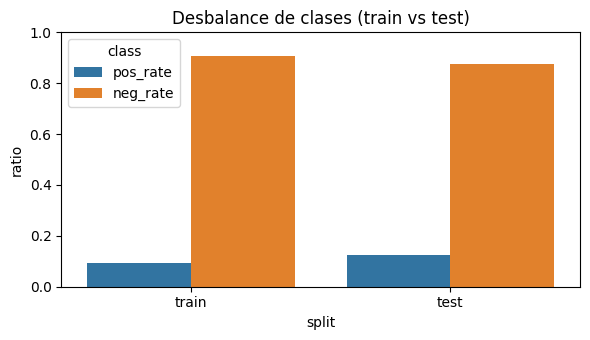

In [10]:
# 1) Diagnóstico de desbalance (solo train/test actuales)
imb_df, _, _ = fc.plot_class_balance(y_train, y_test)
display(imb_df)

In [11]:
# 2) Definir variantes estándar de balanceo (centralizadas en functions.py)
variants = fc.build_default_lr_balance_variants(
    c=1.0,
    max_iter=4000,
    random_state=0,
    sampling_strategy=0.5
)

In [12]:
# 3) Ejecutar variantes (mismo split temporal, mismo test)
tabla_balance, artifacts = fc.run_balance_variants(
    variants=variants,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    train_df=train_df, test_df=test_df
)

display(tabla_balance)

,variante,train_pos_rate_after,acc,bal_acc,f1_pos,top1_hit,top2_hit
0,LR_smote_0.5,0.333332,0.908642,0.862106,0.688573,0.766046,0.862894
1,LR_over_0.5,0.333332,0.882074,0.864772,0.643158,0.764147,0.858336
2,LR_under_0.5,0.333333,0.882889,0.864264,0.644127,0.764147,0.858336
3,LR_class_weight_balanced,0.094534,0.836514,0.848448,0.571787,0.772503,0.858336
4,LR_base,0.094534,0.933484,0.782749,0.688104,0.759590,0.858336


## Cierre Day 04 · Tuning, desbalance y export

- Se aplicó tuning con validación temporal y se compararon variantes de balanceo sobre el mismo split fijo (`train = pasado`, `test = futuro`).
- La selección del champion se hizo con regla determinista orientada a negocio: `Top-2` > `balanced_accuracy` > `f1_pos`.
- `accuracy` por fila no se usa como métrica principal por el desbalance; se priorizan métricas por evento (`Top-1/Top-2`) junto con métricas de clase positiva.
- El modelo solo se promueve si mejora de forma estable frente a los baselines operativos (`más barato`, `siempre proveedor top-1 train`, `top-1 + top-2 train`).
- El champion de Day 04 se exporta en `models/public/baseline/` con `model.pkl` y `metadata.json` reproducible.
- Riesgo principal: dependencia de distribución histórica dominante; siguiente paso: inferencia asistida + validación en Streamlit con anonimización para demo pública.


In [13]:
# Guardado de champion Day 04

import importlib
fc = importlib.reload(fc)

grid_params_map = {
    "LogisticRegression (grid)": grid_lr.best_params_,
    "GradientBoosting (grid)": grid_gb.best_params_,
}

leaderboard = fc.build_day04_leaderboard(
    summary_df=summary,
    balance_df=tabla_balance,
    grid_params_map=grid_params_map,
    run_prefix="day04",
)
champion = leaderboard.iloc[0].to_dict()

champion_model, champion_Xtr = fc.refit_day04_champion_model(
    model_variant=champion["model_variant"],
    grid_lr_estimator=grid_lr.best_estimator_,
    grid_gb_estimator=grid_gb.best_estimator_,
    X_train_hyper=X_train_hyper,
    y_train_hyper=y_train_hyper,
    X_train=X_train,
    y_train=y_train,
    c=1.0,
    max_iter=4000,
    random_state=0,
    sampling_strategy=0.5,
)

metrics_payload = {
    "top1_hit": float(champion["top1_hit"]),
    "top2_hit": float(champion["top2_hit"]),
    "test_acc": float(champion["test_acc"]),
    "test_bal_acc": float(champion["test_bal_acc"]),
    "test_f1_pos": float(champion["test_f1_pos"]),
    "cv_bal_acc": None if pd.isna(champion.get("cv_bal_acc")) else float(champion["cv_bal_acc"]),
}

project_root = Path.cwd().parent
model_dir = project_root / "models" / "day04_champion_tuned"

model_path, metadata_path, _ = fc.save_champion_artifacts(
    model=champion_model,
    model_dir=model_dir,
    model_name=champion["model_variant"],
    metrics=metrics_payload,
    cutoff_date=cutoff_date,
    dataset_name="dataset_modelo_proveedor_v2_candidates.csv",
    feature_columns=champion_Xtr.columns,
    selection_rule="top2_hit DESC -> test_bal_acc DESC -> test_f1_pos DESC",
)

display(leaderboard[["model_variant", "search_type", "test_acc", "test_bal_acc", "test_f1_pos", "top1_hit", "top2_hit", "is_champion"]])
print(f"Champion guardado en: {model_path}")
print(f"Metadata guardada en: {metadata_path}")

,model_variant,search_type,test_acc,test_bal_acc,test_f1_pos,top1_hit,top2_hit,is_champion
0,LR_smote_0.5,imbalance_variant,0.908642,0.862106,0.688573,0.766046,0.862894,1
1,LR_over_0.5,imbalance_variant,0.882074,0.864772,0.643158,0.764147,0.858336,0
2,LR_under_0.5,imbalance_variant,0.882889,0.864264,0.644127,0.764147,0.858336,0
3,LogisticRegression (grid),grid,0.836514,0.848448,0.571787,0.772503,0.858336,0
4,LR_class_weight_balanced,imbalance_variant,0.836514,0.848448,0.571787,0.772503,0.858336,0
5,LR_base,imbalance_variant,0.933484,0.782749,0.688104,0.759590,0.858336,0
6,GradientBoosting (grid),grid,0.931421,0.786280,0.685576,0.777440,0.851880,0


Champion guardado en: ./models/day04_champion_tuned/model.pkl
Metadata guardada en: ./models/day04_champion_tuned/metadata.json
